In [5]:
import pandas as pd
import matplotlib.pyplot as plt
pd.options.display.float_format = "{:,.0f}".format

tx = pd.read_csv("data/transacciones.csv", parse_dates=["date"])
cl = pd.read_csv("data/clientes.csv", parse_dates=["signup_date"])
print(tx.shape, cl.shape)
tx.info()

(11186, 8) (1500, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11186 entries, 0 to 11185
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  11186 non-null  object        
 1   customer_id     11186 non-null  object        
 2   date            11186 non-null  datetime64[ns]
 3   category        11186 non-null  object        
 4   channel         11186 non-null  object        
 5   quantity        11186 non-null  int64         
 6   unit_price      11156 non-null  float64       
 7   discount_pct    11186 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 699.2+ KB


In [6]:
print("Duplicados:", tx.duplicated().sum())
print("Nulos:\n", tx.isna().sum())
print("Cantidades <= 0:", (tx["quantity"] <= 0).sum())
print("Ciudades:\n", cl["city"].value_counts(dropna=False))

Duplicados: 50
Nulos:
 transaction_id     0
customer_id        0
date               0
category           0
channel            0
quantity           0
unit_price        30
discount_pct       0
dtype: int64
Cantidades <= 0: 40
Ciudades:
 city
Bogotá          572
Medellín        349
Cali            210
Barranquilla    170
Bucaramanga     117
NaN              25
BOGOTÁ           20
MEDELLÍN         19
CALI              9
BARRANQUILLA      6
BUCARAMANGA       3
Name: count, dtype: int64


In [7]:
tx = tx.drop_duplicates()
tx = tx[tx["quantity"] > 0].dropna(subset=["unit_price"])
cl["city"] = cl["city"].str.title().fillna("Desconocida")
tx["net_revenue"] = tx["quantity"] * tx["unit_price"] * (1 - tx["discount_pct"])
df = tx.merge(cl, on="customer_id", how="left")
df.shape

(11066, 13)

C:\Users\ssa18\AppData\Local\Temp\ipykernel_14536\1706425039.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  mensual = df.set_index("date").resample("M")["net_revenue"].sum()


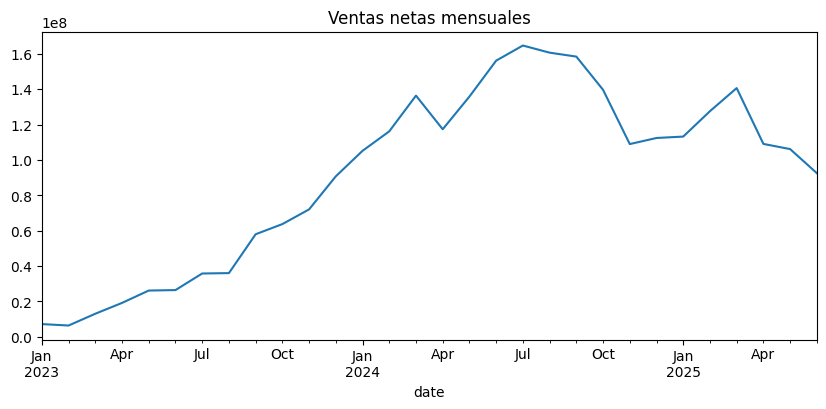

Pico: 164,692,070 en Jul-2024
Último mes: 92,472,290  ->  variación: -44%


In [8]:
mensual = df.set_index("date").resample("M")["net_revenue"].sum()
mensual.plot(title="Ventas netas mensuales", figsize=(10, 4))
plt.show()

pico = mensual.max()
ultimo = mensual.iloc[-1]
print(f"Pico: {pico:,.0f} en {mensual.idxmax():%b-%Y}")
print(f"Último mes: {ultimo:,.0f}  ->  variación: {(ultimo/pico - 1):.0%}")

In [9]:
for col in ["city", "category", "channel", "segment"]:
    t = df.groupby(col)["net_revenue"].agg(["sum", "mean", "count"]).sort_values("sum", ascending=False)
    t["pct_ventas"] = t["sum"] / t["sum"].sum() * 100
    display(t)

,sum,mean,count,pct_ventas
city,,,,
Bogotá,"1,068,431,010","246,694",4331,39
Medellín,"685,550,880","244,316",2806,25
Cali,"391,065,780","245,029",1596,14
Barranquilla,"325,382,980","256,409",1269,12
Bucaramanga,"233,924,040","269,809",867,8
Desconocida,"49,692,850","252,248",197,2


,sum,mean,count,pct_ventas
category,,,,
Tecnología,"1,115,228,600","1,235,026",903,40
Moda,"526,407,790","286,091",1840,19
Hogar,"514,554,630","231,990",2218,19
Mercado,"384,788,410","85,623",4494,14
Belleza,"213,068,110","132,258",1611,8


,sum,mean,count,pct_ventas
channel,,,,
Tienda,"1,356,655,040","246,441",5505,49
App,"854,736,550","255,833",3341,31
Web,"542,655,950","244,440",2220,20


,sum,mean,count,pct_ventas
segment,,,,
Regular,"1,111,844,430","248,124",4481,40
Premium,"933,316,680","250,420",3727,34
Nuevo,"708,886,430","248,036",2858,26


In [10]:
lealtad = df.groupby("loyalty_member").agg(
    clientes=("customer_id", "nunique"),
    ventas=("net_revenue", "sum"),
    ticket_promedio=("net_revenue", "mean"))
lealtad["ventas_por_cliente"] = lealtad["ventas"] / lealtad["clientes"]
lealtad

,clientes,ventas,ticket_promedio,ventas_por_cliente
loyalty_member,,,,
No,905,"1,425,584,100","256,400","1,575,231"
Sí,590,"1,328,463,440","241,276","2,251,633"
